# Simple local quadratic peak refinement

This notebook tests a minimal local quadratic fit for refining the x-position of a maximum in short, unevenly sampled curves.
This is used to interpolate peak of tuning curves.

Design choices:

- only the fitted/refined `x_peak` is returned as the main result;
- no extrapolation is ever used;
- if the discrete maximum is the leftmost or rightmost point, the function returns that edge x directly;
- the minimum information needed to reproduce the fitted curve is stored as 5 numbers:

```python
(a, b, c, x_min_fit, x_max_fit)
```

In [26]:
import numpy as np
import matplotlib.pyplot as plt

## Fitting functions

In [27]:
def refine_peak_x_quadratic(x, y, n_points=4):
    """
    Return refined x-position of the maximum using a local quadratic fit.

    Returns
    -------
    x_peak : float
        Refined x-position of the maximum.
        If fitting is not safe, this is the discrete maximum x.

    fit_info : tuple or None
        Minimal information needed to reproduce the fitted curve:
            (a, b, c, x_min_fit, x_max_fit)

        If None, no accepted fit was used.
    """

    def _local_peak_indices(x, y, imax, n_points=4):
        """
        Select local fit points around the maximum.

        For n_points=4:
        - maximum point
        - stronger immediate neighbor
        - one more point outside the pair on each side, if available
        """
        n = len(x)
        n_points = max(3, min(int(n_points), n))

        if n <= n_points:
            return np.arange(n)

        if n_points % 2 == 1:
            half = n_points // 2
            start = max(0, imax - half)
            stop = min(n, start + n_points)
            start = max(0, stop - n_points)
            return np.arange(start, stop)

        # Even n_points: use max + stronger immediate neighbor as core.
        # This function is called only for non-edge maxima.
        if y[imax - 1] >= y[imax + 1]:
            lo, hi = imax - 1, imax
        else:
            lo, hi = imax, imax + 1

        selected = set(range(lo, hi + 1))
        left = lo - 1
        right = hi + 1

        while len(selected) < n_points and (left >= 0 or right < n):
            if left >= 0 and len(selected) < n_points:
                selected.add(left)
                left -= 1
            if right < n and len(selected) < n_points:
                selected.add(right)
                right += 1

        return np.array(sorted(selected), dtype=int)

    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) == 0:
        return np.nan, None

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    imax = int(np.argmax(y))
    x0 = float(x[imax])

    # Edge maximum: return the edge. Never extrapolate.
    if imax == 0 or imax == len(x) - 1:
        return x0, None

    if len(x) < 3:
        return x0, None

    idx = _local_peak_indices(x, y, imax, n_points=n_points)
    if len(idx) < 3:
        return x0, None

    xf = x[idx]
    yf = y[idx]

    a, b, c = np.polyfit(xf, yf, deg=2)

    # A maximum requires a downward-opening parabola.
    if not np.isfinite(a) or not np.isfinite(b) or a >= 0:
        return x0, None

    x_peak = float(-b / (2 * a))

    # No extrapolation: accept only inside fitted data range.
    if x_peak < xf.min() or x_peak > xf.max():
        return x0, None

    fit_info = (float(a), float(b), float(c), float(xf.min()), float(xf.max()))
    return x_peak, fit_info

def restore_fit_curve(fit_info, n_points=100):
    if fit_info is None:
        raise ValueError("fit_info cannot be None")
    a, b, c, x_min_fit, x_max_fit = fit_info
    x_fit = np.linspace(x_min_fit, x_max_fit, n_points)
    y_fit = a * x_fit**2 + b * x_fit + c
    return x_fit, y_fit

## Plot helper

This is only for testing/visualization.

In [28]:
def plot_peak_test(x, y, n_points=4, title=""):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    order = np.argsort(x)
    xs = x[order]
    ys = y[order]

    x_peak, fit_info = refine_peak_x_quadratic(xs, ys, n_points=n_points)
    imax = int(np.argmax(ys))
    x_discrete = float(xs[imax])

    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys, "o-", label="data")
    plt.axvline(x_discrete, linestyle="--", linewidth=1, label=f"discrete max = {x_discrete:.3g}")
    plt.axvline(x_peak, linestyle=":", linewidth=2, label=f"returned x_peak = {x_peak:.3g}")

    if fit_info is not None:
        #a, b, c, x_min, x_max = fit_info
        #x_fit = np.linspace(x_min, x_max, 100)
        #y_fit = a*x_fit**2 + b*x_fit + c
        x_fit, y_fit = restore_fit_curve(fit_info)
        plt.plot(x_fit, y_fit, linewidth=2, label="accepted local quadratic")

        #idx = _local_peak_indices(xs, ys, imax, n_points=n_points)
        #plt.scatter(xs[idx], ys[idx], s=100, facecolors="none", linewidths=2, label="fit points")
    else:
        plt.text(
            0.02, 0.95,
            "fit_info=None\nreturned discrete/edge maximum",
            transform=plt.gca().transAxes,
            va="top",
        )

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("x_peak:", x_peak)
    print("fit_info:", fit_info)
    return x_peak, fit_info

## Test 1: interior maximum, uneven x, `n_points=4`

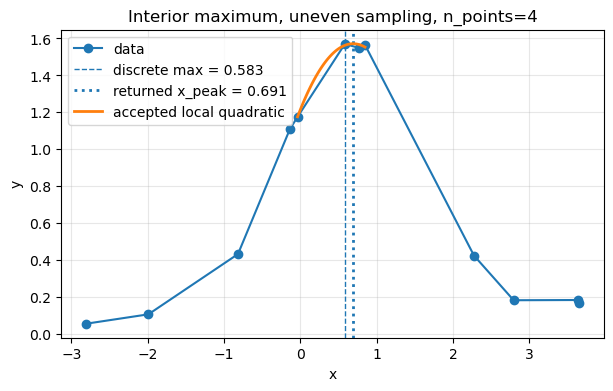

x_peak: 0.6909433954673959
fit_info: (-0.7470302636896086, 1.0323112538212045, 1.2147554030135135, -0.03671485719197065, 0.8471558137114164)
true peak: 0.7


In [29]:
rng = np.random.default_rng(1)

x = np.sort(rng.uniform(-3, 4, size=12))
true_peak = 0.7
y = 1.5 * np.exp(-0.5 * ((x - true_peak) / 0.9)**2) + 0.1
y += rng.normal(scale=0.06, size=len(x))

x_peak, fit_info = plot_peak_test(
    x, y,
    n_points=4,
    title="Interior maximum, uneven sampling, n_points=4"
)

print("true peak:", true_peak)

## Test 2: leftmost point is the maximum

Expected behavior: return the left edge and `fit_info=None`.

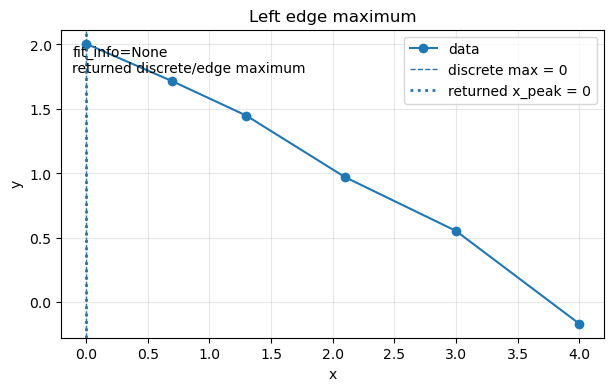

x_peak: 0.0
fit_info: None


In [30]:
rng = np.random.default_rng(2)

x_left = np.array([0.0, 0.7, 1.3, 2.1, 3.0, 4.0])
y_left = 2.0 - 0.35*x_left - 0.05*x_left**2
y_left += rng.normal(scale=0.03, size=len(x_left))

x_peak, fit_info = plot_peak_test(
    x_left, y_left,
    n_points=4,
    title="Left edge maximum"
)

assert x_peak == x_left[0]
assert fit_info is None

## Test 3: rightmost point is the maximum

Expected behavior: return the right edge and `fit_info=None`.

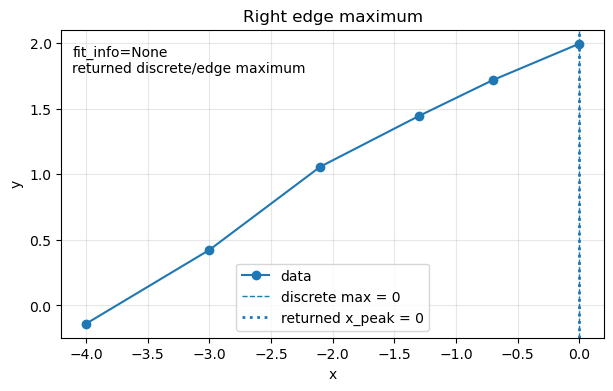

x_peak: 0.0
fit_info: None


In [31]:
rng = np.random.default_rng(3)

x_right = np.array([-4.0, -3.0, -2.1, -1.3, -0.7, 0.0])
y_right = 2.0 + 0.35*x_right - 0.05*x_right**2
y_right += rng.normal(scale=0.03, size=len(x_right))

x_peak, fit_info = plot_peak_test(
    x_right, y_right,
    n_points=4,
    title="Right edge maximum"
)

assert x_peak == x_right[-1]
assert fit_info is None

## Test 4: compare `n_points=3`, `4`, and `5`


--- n_points = 3 ---


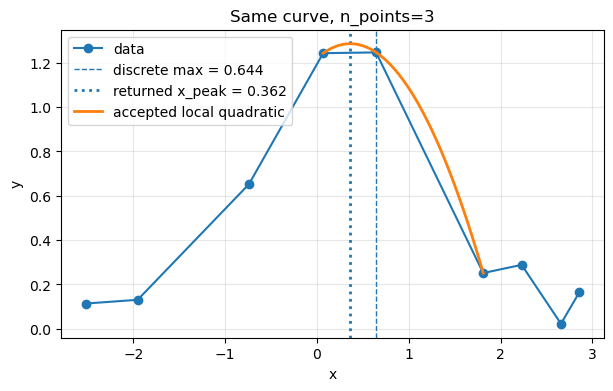

x_peak: 0.3623366850692674
fit_info: (-0.49273787805205577, 0.3570740186828936, 1.2215374298015664, 0.0679653168861698, 1.8114072419148437)

--- n_points = 4 ---


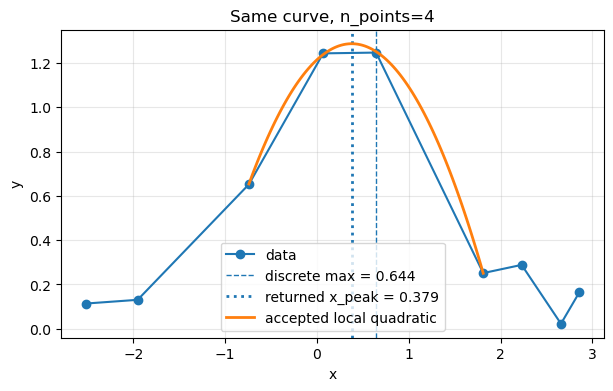

x_peak: 0.3788758190674029
fit_info: (-0.5050313524418468, 0.3826883346222459, 1.214665043464932, -0.7410804937363649, 1.8114072419148437)

--- n_points = 5 ---


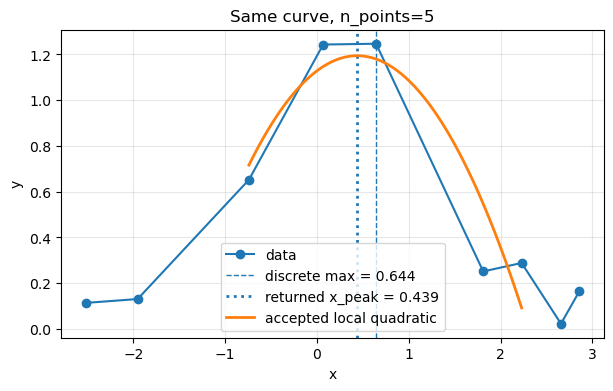

x_peak: 0.4385969958806106
fit_info: (-0.34358974618888094, 0.3013948609876493, 1.128454753521586, -0.7410804937363649, 2.229811645125938)
true peak: 0.35


In [32]:
rng = np.random.default_rng(4)

x_cmp = np.sort(rng.uniform(-3, 3, size=9))
true_peak = 0.35
y_cmp = 1.2 * np.exp(-0.5 * ((x_cmp - true_peak) / 0.8)**2) + 0.1
y_cmp += rng.normal(scale=0.05, size=len(x_cmp))

for n_points in [3, 4, 5]:
    print("\n--- n_points =", n_points, "---")
    plot_peak_test(
        x_cmp, y_cmp,
        n_points=n_points,
        title=f"Same curve, n_points={n_points}"
    )

print("true peak:", true_peak)

## Test 5: random short curves, 5–15 points

This is a quick stress test for uneven x and short curves.

0: n=12, true= 2.371, discrete= 2.464, returned= 2.332, fit_used=True


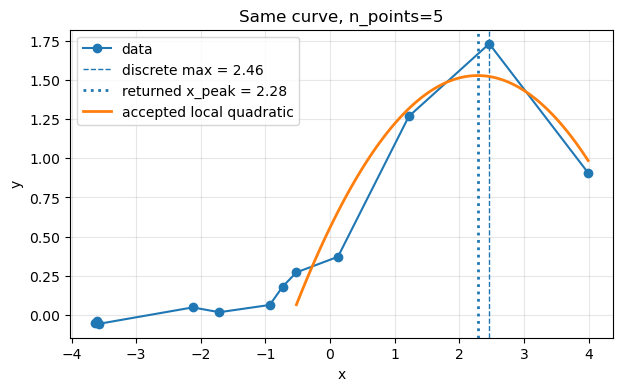

x_peak: 2.284880870803063
fit_info: (-0.18603787671796337, 0.8501487715153859, 0.5577029150387359, -0.5204195821988638, 3.9934089205205714)
1: n=13, true=-0.901, discrete=-0.507, returned=-0.822, fit_used=True


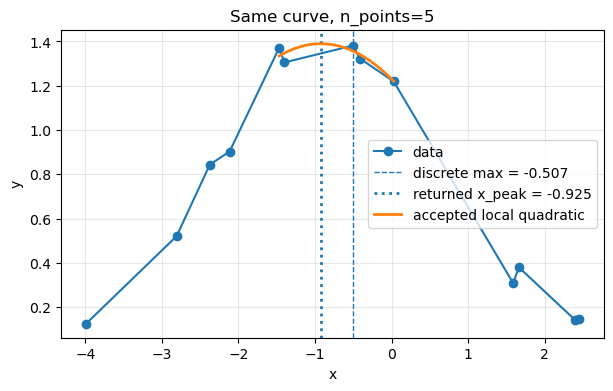

x_peak: -0.925277956326952
fit_info: (-0.18718102421546462, -0.3463889510985416, 1.2294878122772814, -1.4683833007640787, 0.026911724429315775)
2: n=12, true= 0.563, discrete= 1.083, returned= 0.554, fit_used=True


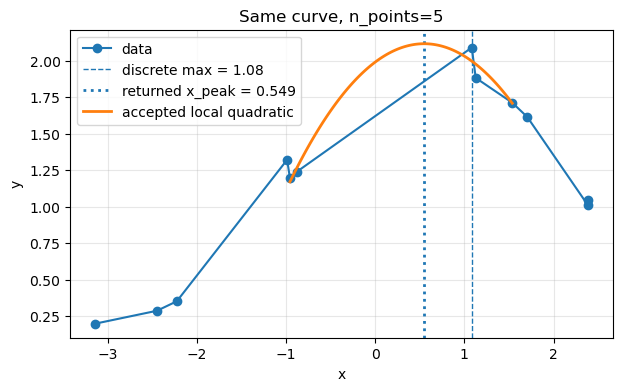

x_peak: 0.5490348291564604
fit_info: (-0.4174277292038614, 0.4583647239772225, 1.9898027461185723, -0.9561970348534112, 1.537778197158639)
3: n=10, true= 1.644, discrete= 2.586, returned= 1.332, fit_used=True


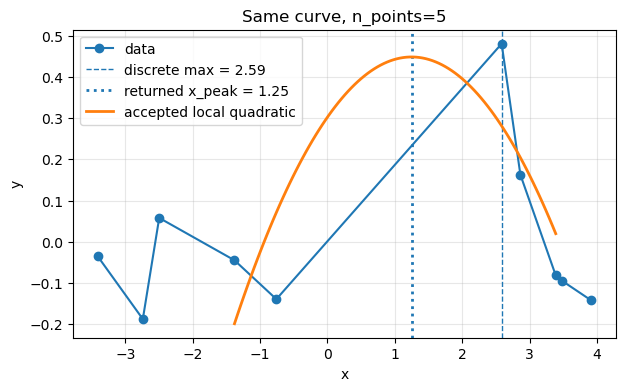

x_peak: 1.2488886168046514
fit_info: (-0.09368197725312281, 0.23399670998235472, 0.30269443787908945, -1.3812014934072172, 3.389412678061877)
4: n=10, true= 0.954, discrete= 0.752, returned= 0.901, fit_used=True


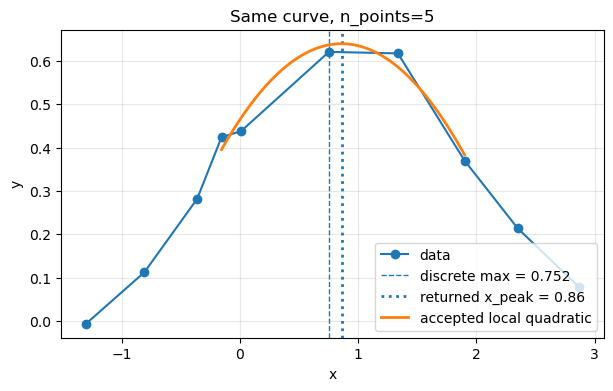

x_peak: 0.8596133278286555
fit_info: (-0.23666665359692787, 0.40688361936905365, 0.46457092158814794, -0.15599186683082866, 1.8997358623218155)
5: n=14, true=-2.285, discrete=-2.155, returned=-2.369, fit_used=True


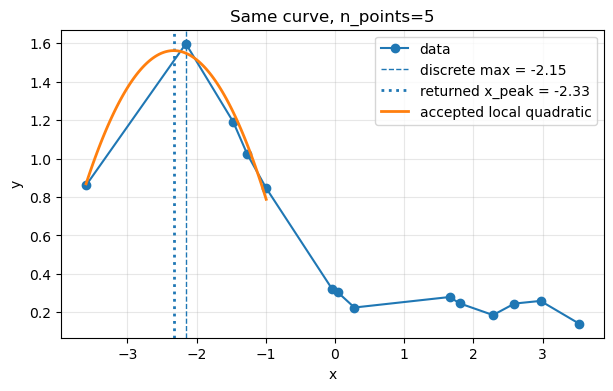

x_peak: -2.3311026094487293
fit_info: (-0.4332363714544473, -2.019836872011122, -0.7919414721873164, -3.5963966907358325, -0.9943996681623073)
6: n=13, true= 0.008, discrete=-0.452, returned= 0.057, fit_used=True


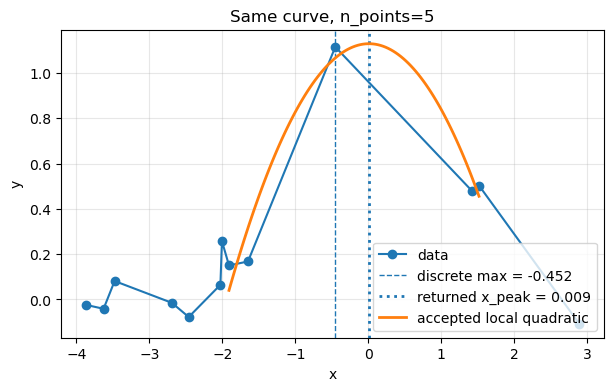

x_peak: 0.009004041343917161
fit_info: (-0.2960767235082591, 0.00533177411887979, 1.128817015755934, -1.90849156417588, 1.5169808015125277)
7: n=15, true= 1.299, discrete= 1.006, returned= 1.508, fit_used=True


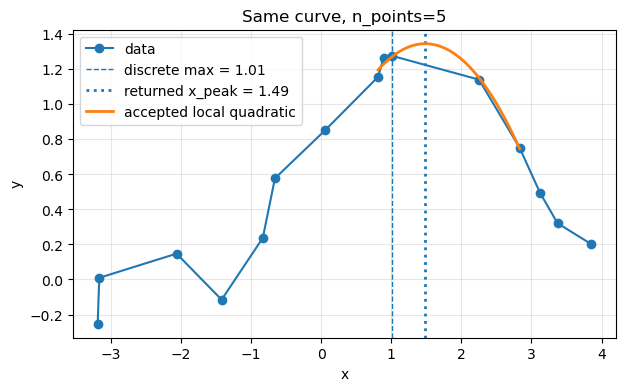

x_peak: 1.485475222167137
fit_info: (-0.33078659598435334, 0.9827505843195365, 0.6162186380215886, 0.81256184991694, 2.832311483092375)


In [33]:
rng = np.random.default_rng(5)

for i in range(8):
    n = int(rng.integers(5, 16))
    x = np.sort(rng.uniform(-4, 4, size=n))

    true_peak = rng.uniform(-2.5, 2.5)
    width = rng.uniform(0.5, 1.5)
    amplitude = rng.uniform(0.8, 2.0)
    baseline = rng.uniform(-0.2, 0.3)
    noise = rng.uniform(0.03, 0.12)

    y = amplitude * np.exp(-0.5 * ((x - true_peak) / width)**2) + baseline
    y += rng.normal(scale=noise, size=n)

    x_peak, fit_info = refine_peak_x_quadratic(x, y, n_points=4)
    x_discrete = x[np.argmax(y)]

    print(
        f"{i}: n={n:2d}, true={true_peak: .3f}, "
        f"discrete={x_discrete: .3f}, returned={x_peak: .3f}, "
        f"fit_used={fit_info is not None}"
    )
    plot_peak_test(
        x, y,
        n_points=n_points,
        title=f"Same curve, n_points={n_points}"
    )


## Storage summary

For each curve, store:

```python
x_peak
```

That is enough if you only need the refined maximum.

To reproduce the fitted curve later, store:

```python
fit_info = (a, b, c, x_min_fit, x_max_fit)
```

That is **5 numbers**. Then reconstruct with:

```python
a, b, c, x_min, x_max = fit_info
x_fit = np.linspace(x_min, x_max, 100)
y_fit = a*x_fit**2 + b*x_fit + c
```

For edge maxima or rejected fits, `fit_info=None`.